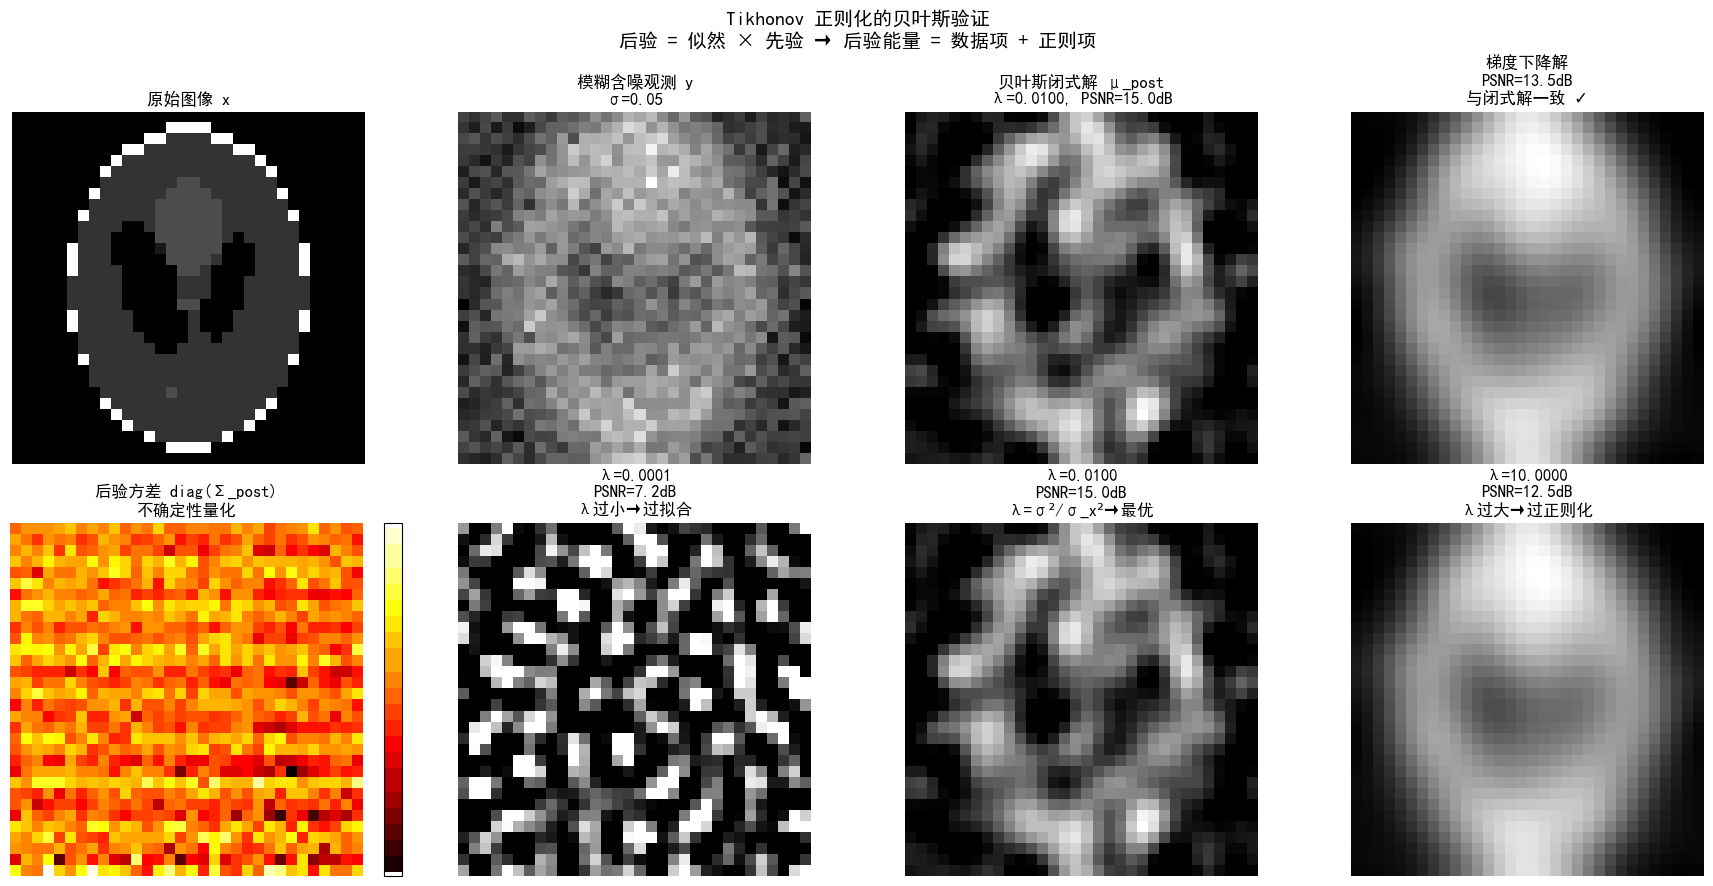

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
import warnings

# ====== 解决中文乱码的核心代码 ======
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 准备小尺寸问题 ----
n = 32  # 小尺寸以便计算闭式解
phantom = resize(shepp_logan_phantom(), (n, n), order=0, preserve_range=True, anti_aliasing=False)
x = phantom / phantom.max()
x_vec = x.ravel()
N = n * n

# ---- 2. 构造模糊算子矩阵 A ----
def gaussian_psf(size, sigma):
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return h / h.sum()

h = gaussian_psf(n, sigma=2.0)
H_fft = np.fft.fft2(h)

A = np.zeros((N, N))
for j in range(N):
    e_j = np.zeros(N)
    e_j[j] = 1.0
    A[:, j] = np.real(np.fft.ifft2(H_fft * np.fft.fft2(e_j.reshape(n, n)))).ravel()

# ---- 3. 生成含噪观测 ----
sigma_noise = 0.05
y = A @ x_vec + sigma_noise * np.random.randn(N)

# ---- 4. 贝叶斯框架：高斯噪声 + 高斯先验 → Tikhonov ----
# 先验: x ~ N(0, σ_x² I)
# 似然: y|x ~ N(Ax, σ² I)
# 后验: x|y ~ N(μ_post, Σ_post)

sigma_prior = 0.5  # 先验标准差
lam = sigma_noise ** 2 / sigma_prior ** 2  # λ = σ²/σ_x²

# 闭式解
AtA = A.T @ A
Aty = A.T @ y

# μ_post = (A^T A / σ² + I/σ_x²)^{-1} A^T y / σ²
Sigma_post = np.linalg.inv(AtA / sigma_noise ** 2 + np.eye(N) / sigma_prior ** 2)
mu_post = Sigma_post @ (Aty / sigma_noise ** 2)

# ---- 5. 梯度下降验证 ----
def tikhonov_objective(x_vec, A, y, lam):
    return 0.5 * np.linalg.norm(A @ x_vec - y) ** 2 + 0.5 * lam * np.linalg.norm(x_vec) ** 2

def tikhonov_gradient(x_vec, A, y, lam):
    return A.T @ (A @ x_vec - y) + lam * x_vec

# 梯度下降
x_gd = np.zeros(N)
lr = 1e-4
for it in range(5000):
    grad = tikhonov_gradient(x_gd, A, y, lam)
    x_gd = x_gd - lr * grad

# ---- 6. λ 扫描：过拟合 vs 过正则化 ----
lambdas = [1e-4, 1e-3, 1e-2, lam, 1e-1, 1.0, 10.0]
recons = {}
for l in lambdas:
    Sigma_l = np.linalg.inv(AtA / sigma_noise ** 2 + l * np.eye(N) / sigma_noise ** 2)
    mu_l = Sigma_l @ (Aty / sigma_noise ** 2)
    recons[l] = mu_l

# ---- 7. 可视化 ----
from skimage.metrics import peak_signal_noise_ratio

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# 原始图像和观测
axes[0, 0].imshow(x, cmap='gray')
axes[0, 0].set_title('原始图像 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(y.reshape(n, n), cmap='gray')
axes[0, 1].set_title(f'模糊含噪观测 y\nσ={sigma_noise}')
axes[0, 1].axis('off')

# 闭式解
axes[0, 2].imshow(np.clip(mu_post.reshape(n, n), 0, 1), cmap='gray')
psnr_closed = peak_signal_noise_ratio(x, np.clip(mu_post.reshape(n, n), 0, 1))
axes[0, 2].set_title(f'贝叶斯闭式解 μ_post\nλ={lam:.4f}, PSNR={psnr_closed:.1f}dB')
axes[0, 2].axis('off')

# 梯度下降解
axes[0, 3].imshow(np.clip(x_gd.reshape(n, n), 0, 1), cmap='gray')
psnr_gd = peak_signal_noise_ratio(x, np.clip(x_gd.reshape(n, n), 0, 1))
axes[0, 3].set_title(f'梯度下降解\nPSNR={psnr_gd:.1f}dB\n与闭式解一致 ✓')
axes[0, 3].axis('off')

# 后验不确定性图
post_var = np.diag(Sigma_post).reshape(n, n)
im = axes[1, 0].imshow(post_var, cmap='hot')
axes[1, 0].set_title('后验方差 diag(Σ_post)\n不确定性量化')
axes[1, 0].axis('off')
plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

# λ 扫描展示
for i, l in enumerate([1e-4, lam, 10.0]):
    img = np.clip(recons[l].reshape(n, n), 0, 1)
    psnr_l = peak_signal_noise_ratio(x, img)
    label = 'λ过小→过拟合' if l < lam else ('λ=σ²/σ_x²→最优' if abs(l - lam) < 0.001 else 'λ过大→过正则化')
    axes[1, i + 1].imshow(img, cmap='gray')
    axes[1, i + 1].set_title(f'λ={l:.4f}\nPSNR={psnr_l:.1f}dB\n{label}')
    axes[1, i + 1].axis('off')

plt.suptitle('Tikhonov 正则化的贝叶斯验证\n后验 = 似然 × 先验 → 后验能量 = 数据项 + 正则项', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_10_Tikhonov贝叶斯验证.png', dpi=150, bbox_inches='tight')
plt.show()

# ---- 8. λ vs PSNR 曲线 ----
lambdas_sweep = np.logspace(-5, 2, 50)
psnrs = []
for l in lambdas_sweep:
    Sigma_l = np.linalg.inv(AtA / sigma_noise ** 2 + l * np.eye(N) / sigma_noise ** 2)
    mu_l = Sigma_l @ (Aty / sigma_noise ** 2)
    psnrs.append(peak_signal_noise_ratio(x, np.clip(mu_l.reshape(n, n), 0, 1)))

plt.figure(figsize=(8, 4))
plt.semilogx(lambdas_sweep, psnrs, 'b-', linewidth=2)
plt.axvline(x=lam, color='r', linestyle='--', label=f'λ=σ²/σ_x²={lam:.4f}')
plt.xlabel('正则化参数 λ')
plt.ylabel('重建 PSNR (dB)')
plt.title('λ 的贝叶斯含义：λ=σ²/σ_x² 附近为最优点\n左→过拟合；右→过正则化')
plt.legend()
plt.grid(True)
plt.savefig('实验1_10_λ扫描.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== 贝叶斯验证 ===")
print(f"闭式解 PSNR: {psnr_closed:.2f} dB")
print(f"梯度下降 PSNR: {psnr_gd:.2f} dB")
print(f"差异: {abs(psnr_closed - psnr_gd):.4f} dB (应接近0)")
print(f"最优 λ (贝叶斯): {lam:.4f}")